In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import pandas as pd

In [2]:
# sgplassodiagobsmod8C1.m1.20180709.120000.nc   combined arscl and wrf timeseries
# sgplassodiagobsmodz8C1.m1.20180709.120000.nc  simuation and arscl 2D cloud fraction, time and z
# sgplassomod8C1.m1.20180709.120000.nc          simulation profiles 

In [3]:
files = glob("/data/project/ARM_Summer_School_2026/data/modeling/lasso/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 
in_paths = list(compress(files , [('modz' not in f) and ('5C1' not in f) for f in files]))

ds_all = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


In [4]:
files = glob("/data/project/ARM_Summer_School_2026/data/modeling/lasso/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 
in_paths = list(compress(files , [('modz' not in f) and ('5C1' not in f) for f in files]))

ds_all = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')
ds_all = ds_all.assign_coords(time=ds_all.time - pd.Timedelta(hours=6))

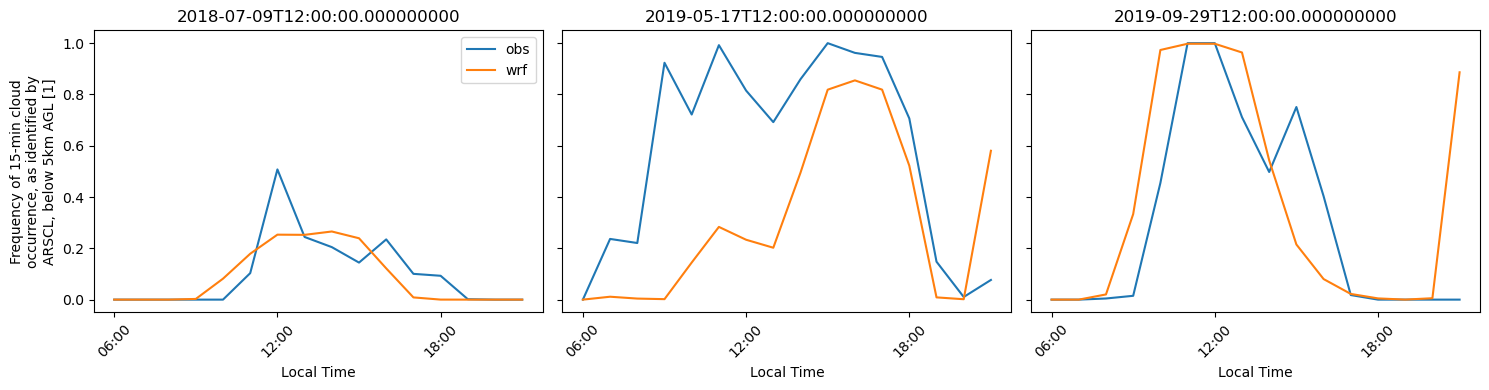

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, ax in enumerate(axes):
  ds_all['low_cloud_fraction_arscl'].sel(source_type=0).isel(date=i).plot(
      ax=ax, label="obs"
  )
  ds_all['low_cloud_fraction_arscl'].sel(source_type=1).isel(date=i).plot(
      ax=ax, label="wrf"
  )
  
  date_label =  np.unique(ds_all.isel(date= i).time_offset.values)[0]
  ax.set_title(date_label)

  ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
  ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
  plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
  ax.set_xlabel("Local Time")
  if i > 0:
      ax.set_ylabel("")

axes[0].legend()
plt.tight_layout()
plt.show()

In [6]:
files = glob("/data/project/ARM_Summer_School_2026/data/modeling/lasso/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 
in_paths = list(compress(files , [('modz' in f) and ('5C1' not in f) for f in files]))

ds_2d = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')
ds_2d = ds_2d.assign_coords(time=ds_2d.time - pd.Timedelta(hours=6))

In [7]:
ds_2d

<xarray.Dataset> Size: 2MB
Dimensions:                    (date: 3, time: 273, height: 226)
Coordinates:
    height                     (time, height) float32 247kB nan nan ... nan nan
  * time                       (time) datetime64[ns] 2kB 2018-07-09T06:00:00 ...
Dimensions without coordinates: date
Data variables:
    base_time                  (date) datetime64[ns] 24B 2018-07-09 ... 2019-...
    time_offset                (date, time) datetime64[ns] 7kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    cloud_fraction             (date, time, height) float32 740kB dask.array<chunksize=(1, 5, 226), meta=np.ndarray>
    cloud_fraction_mask_arscl  (date, time, height) float32 740kB dask.array<chunksize=(1, 5, 226), meta=np.ndarray>
    lat                        (date) float32 12B 36.6 36.6 36.6
    lon                        (date) float32 12B -97.49 -97.49 -97.49
    alt                        (date) float32 12B 318.0 318.0 318.0
Attributes: (12/34)
    command_line:                          lassodiagobsmodz -n lassodiagobsmo...
    Conventions:                           ARM-1.2
    process_version:                       vap-lassodiagobsmodz-1.1-1.el7
    dod_version:                           lassodiagobsmodz8-m1-1.0
    input_datastreams:                     sgpcldfracset15mC1.c1 : 1.2 : 2018...
    site_id:                               sgp
    ...                                    ...
    config_boundary_method:                Periodic
    config_microphysics:                   Thompson (mp_physics=8)
    config_nickname:                       runlas20180709v1msda2d300km
    contacts:                              lasso@arm.gov, LASSO PI: William G...
    doi:                                   10.5439/1342961
    history:                               created by user ttoto on machine a...